# Fiery results - epochs

## NB y- and x-axis should be inverted

In [1]:
# imports

import numpy as np
from matplotlib import pyplot as plt
from sklearn.metrics import log_loss
import pickle
import torch.nn.functional as F


In [2]:
from helper import get_results, find_gaussians, find_gaussians_cal, get_models_in_rings, find_instance_centers, plot_seg, \
                   generate_rel_diagrams, get_clusters

## 0. Helper functions and static variables

In [3]:
PATH_labels_pedestrians = "labels_val_epoch0_pedestrians"  # Folder name
PATH_res_pedestrians = "results_val_epoch1_pedestrians_e12" # Folder name

PATH_labels_vehicles = "labels_val"
PATH_res_vehicles = "results_val"

PATH_image = "images_val" # Folder name

FILE_label = "labels_val_%i.p"   # Single file name
FILE_res = "results_val_img%i.p"  # Single file name
FILE_image = "image_val_b%i_i%i_s%i_c%i.jpg"  # Single file name

## 1. Get results in the right format

### Generate data for pedestrians

In [4]:
if False:

    segm_ped_y, segm_ped_p, segm_ped_log, inst_ped_y = get_results(PATH_labels_pedestrians,
                                                                   PATH_res_pedestrians,
                                                                   flip_input=True) #ys, preds,  # TODO we can do it faster? - Splitting batches appart

    np.savez("segm_results_pedestrains_e12_full_inst.npz", y=segm_ped_y, p=segm_ped_p, log=segm_ped_log, inst=inst_ped_y)

else:
    segm_ped_data = np.load("segm_results_pedestrains_e12_full_inst.npz")

    segm_ped_y = segm_ped_data["y"]
    segm_ped_p = segm_ped_data["p"]

In [5]:
inst_ped_y = segm_ped_data["inst"]

In [6]:
if False:

    center_ped_y, center_ped_p, _, _ = get_results(PATH_labels_pedestrians,
                                                   PATH_res_pedestrians,
                                                    results_name = "instance_center", label_name = "centerness", 
                                                   flip_input=True, use_softmax = False) #ys, preds,  # TODO we can do it faster? - Splitting batches appart

    np.savez("center_results_pedestrains_e12_full.npz", y=center_ped_y, p=center_ped_p)

else:
    center_ped_data = np.load("center_results_pedestrains_e12_full.npz")

    center_ped_y = segm_ped_data["y"]
    center_ped_p = center_ped_data["p"]

In [7]:
segm_ped_y.shape

(5, 5119, 200, 200)

In [8]:
segm_ped_p.shape

(5, 5119, 200, 200)

In [9]:
center_ped_p.shape

(5, 5119, 200, 200)

In [10]:
inst_ped_y.shape

(5, 5119, 200, 200)

## 2. Generate input data from segmentation

### Check how many pixels make up a pedestrian

In [11]:
nr_future=4
#idx = 200

### Match segmentation and norm-distribution

## Presence Uncertainty

#### Reliability diagrams

## Pixel-wise calibration

In [12]:
if False:
    models_cal, masks_cal, (indices_val, indices_test) = \
        get_models_in_rings(segm_ped_p, segm_ped_y, nr_future = 4, random_state=1001)
    models_cal_c, masks_cal_c, (indices_val_c, indices_test_c) =  \
        get_models_in_rings(center_ped_p, center_ped_y, nr_future = 4, random_state=1001)

In [13]:
if False:  # Skip if no need to rerun

    print("Nr_future:", nr_future)
    
    probs_cal = []
    probs = []
    ys = []
    FNs = []
    dist_means = []
    indices = []


    for count, idx in enumerate(indices_test):
        
        #print(idx)

        if count % 100 == 0:
            print(count)

        segm_cal_full = np.zeros(shape=masks_cal[0].shape)
        center_cal_full = np.zeros(shape=masks_cal_c[0].shape)

        for model, mask in zip(models_cal, masks_cal):
            segm_cal = model.predict(segm_ped_p[nr_future, idx].flatten())
            segm_cal_2d = segm_cal.reshape(200,200)

            #print("Uncal NLL:", log_loss(segm_ped_y[nr_future, idx].flatten(), segm_ped_p[nr_future, idx].flatten()))
            #print("Cal NLL:", log_loss(segm_ped_y[nr_future, idx].flatten(), segm_cal))

            segm_cal_full[mask] = segm_cal_2d[mask]


        segm_p_new = segm_ped_p[nr_future, idx].copy()
        center_ped_p_new = center_ped_p[nr_future, idx].copy()
        segm_p_cal_new = segm_cal_full.copy()

        p, p_cal, dists, masks_gmm, pdfs = find_gaussians_cal(segm_p_new, segm_p_cal_new, center_ped_p_new, 
                                                                      multiplier = 100, conf_threshold=0.1, nms_kernel_size=3)
        cls = get_clusters(segm_ped_y[nr_future, idx])

        ## Match cls with predicted cls
        all_matches = []
        all_matches_cal = []

        if masks_gmm == None:
            continue

        for i, (pr, pr_cal, dist, m) in enumerate(zip(p, p_cal, dists, masks_gmm)):

            #print(pred_cl)

            all_matches.append([[], [], [pr], [pr_cal], [dist.mean], [idx]])

            for n_cl, cl in enumerate(cls):
                matches = np.sum(m[np.array(cl)[:, 1], np.array(cl)[:, 0]])
                match_prob = matches/len(cl)

                if matches != 0:
                    all_matches[i][0].append(n_cl)
                    all_matches[i][1].append(match_prob)

        for res in all_matches:
            probs.append(res[2][0])
            probs_cal.append(res[3][0])
            dist_means.append(res[4])
            ys.append(0 if len(res[0]) == 0 else 1)
            indices.append(res[5])
        #break
    
    dist_means = np.array(dist_means)[:, -1, :]
    probs = np.array(probs)
    probs_cal = np.array(probs_cal)
    ys = np.array(ys)
    indices = np.array(indices)[:, -1]
    
    np.savez("results_presence_uncertainty_traj_09_23_22_v2.npz", p=probs, p_cal=probs_cal, y=ys, dist_mean=dist_means, indices=indices)

In [23]:
# Load data

res_pres_cal = np.load("results_presence_uncertainty_traj_09_23_22_v2.npz")

probs = res_pres_cal["p"]
probs_cal = res_pres_cal["p_cal"]
ys = res_pres_cal["y"]
dist_means = res_pres_cal["dist_mean"]
indices = res_pres_cal["indices"]

In [24]:
probs[:10]

array([ 5.3761473 , 13.650487  ,  3.1737874 , 13.107927  ,  0.72514296,
       13.35525   ,  2.1586125 ,  2.123647  ,  2.6353135 ,  2.5881157 ],
      dtype=float32)

In [25]:
probs_cal[:10]

array([3.14269496, 7.94163583, 2.07985261, 7.57567569, 0.59246284,
       7.75554123, 1.56045704, 1.23940227, 1.45260147, 1.75578619])

In [26]:
np.percentile(probs, 90)

7.080375289916992

In [27]:
probs.max()

44.090157

In [28]:
probs_cal.max()

29.79164979650751

In [29]:
np.quantile(probs, 0.9)

7.080375289916992


ECE_abs: 0.16992507218591418
[238, 249, 228, 206, 188, 243, 204, 216, 213, 11079]
Conf: [0.0497582, 0.15124509, 0.24930194, 0.35106656, 0.45128533, 0.5518933, 0.64992046, 0.7510965, 0.8460411, 0.9991208]
Acc: [0.03361344537815126, 0.1285140562248996, 0.15789473684210525, 0.2912621359223301, 0.324468085106383, 0.35802469135802467, 0.4215686274509804, 0.4583333333333333, 0.4694835680751174, 0.826157595450853]


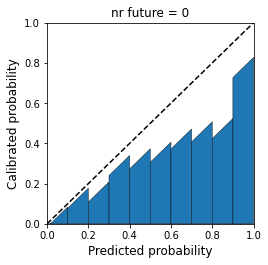

In [30]:
generate_rel_diagrams(np.clip(probs, 0, 1), ys)


ECE_abs: 0.12666740409417115
[331, 330, 310, 290, 371, 359, 384, 431, 443, 9815]
Conf: [0.05024351198046035, 0.14973493715375796, 0.2516866067001114, 0.3492632646674315, 0.4480663685449294, 0.5498742656023552, 0.6522656918406387, 0.7518165347709285, 0.849841753795206, 0.9974648200151561]
Acc: [0.0513595166163142, 0.14242424242424243, 0.29354838709677417, 0.3413793103448276, 0.3665768194070081, 0.4958217270194986, 0.5, 0.5754060324825986, 0.6230248306997742, 0.8597045338767193]


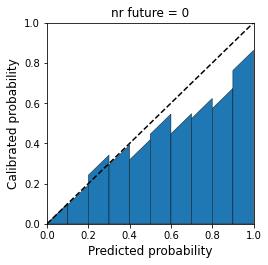

In [31]:
generate_rel_diagrams(np.clip(probs_cal, 0, 1), ys)

In [32]:
# TODO check how the coordinates relate? Is a correct area selected
# Dist means, in which format?

In [33]:
area = np.array([[39,101],[69,131]])
indices_area = np.where((dist_means[:, 0] >= area[0][0]) & (dist_means[:, 0] < area[0][1]) & (dist_means[:, 1] >= area[1][0]) & (dist_means[:, 1] < area[1][1]))

In [34]:
area = np.array([[79,101],[79,121]])
indices_area = np.where((dist_means[:, 0] >= area[0][0]) & (dist_means[:, 0] < area[0][1]) & (dist_means[:, 1] >= area[1][0]) & (dist_means[:, 1] < area[1][1]))


ECE_abs: 0.0557274257970129
[0, 4, 2, 4, 6, 14, 11, 4, 3, 739]
Conf: [nan, 0.1732541, 0.25638783, 0.31594616, 0.44033358, 0.5420062, 0.6600967, 0.75345385, 0.8425495, 0.9991335]
Acc: [nan, 1.0, 0.5, 1.0, 1.0, 0.7142857142857143, 1.0, 1.0, 1.0, 0.9634641407307172]


/home/pohl01/markus93/miniconda3/envs/fiery/lib/python3.7/site-packages/numpy/core/fromnumeric.py:3373: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/home/pohl01/markus93/miniconda3/envs/fiery/lib/python3.7/site-packages/numpy/core/_methods.py:170: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


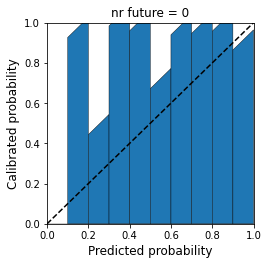

In [35]:
generate_rel_diagrams(np.clip(probs, 0, 1)[indices_area[0]], ys[indices_area[0]])

Praegu GMM'd leitud kalibreerimata andmete põhjal ja otseselt võrreldud neid


ECE_abs: 0.06012215785275363
[0, 4, 6, 5, 17, 12, 7, 16, 13, 707]
Conf: [nan, 0.14837891524587712, 0.25013784489117025, 0.36247814047422455, 0.4469070699040269, 0.5474731424266261, 0.6581378602496784, 0.75785162813733, 0.8387226792498438, 0.9986222849540307]
Acc: [nan, 1.0, 0.8333333333333334, 1.0, 0.7647058823529411, 0.9166666666666666, 0.8571428571428571, 0.875, 1.0, 0.9674681753889675]


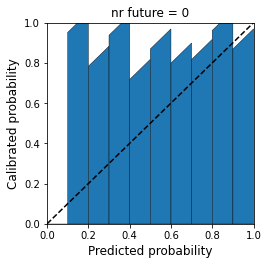

In [36]:
generate_rel_diagrams(np.clip(probs_cal, 0, 1)[indices_area[0]], ys[indices_area[0]])

## Calibrated segm for GMM

In [37]:
if False:

    probs_cal2 = []
    probs2 = []
    ys2 = []
    dist_means2 = []
    indices2 = []

    print("Nr_future:", nr_future)

    for count, idx in enumerate(indices_test):

        if count % 100 == 0:
            print(count)

        # Calib
        segm_cal_full = np.zeros(shape=masks_cal[0].shape)
        center_cal_full = np.zeros(shape=masks_cal_c[0].shape)

        for model, mask in zip(models_cal, masks_cal):
            segm_cal = model.predict(segm_ped_p[nr_future, idx].flatten())
            segm_cal_2d = segm_cal.reshape(200,200)

            #print("Uncal NLL:", log_loss(segm_ped_y[nr_future, idx].flatten(), segm_ped_p[nr_future, idx].flatten()))
            #print("Cal NLL:", log_loss(segm_ped_y[nr_future, idx].flatten(), segm_cal))

            segm_cal_full[mask] = segm_cal_2d[mask]

        for model_c, mask_c in zip(models_cal_c, masks_cal_c):
            center_cal = model_c.predict(center_ped_p[nr_future, idx].flatten())
            center_cal_2d = center_cal.reshape(200,200)

            #print("Uncal NLL:", log_loss(segm_ped_y[nr_future, idx].flatten(), segm_ped_p[nr_future, idx].flatten()))
            #print("Cal NLL:", log_loss(segm_ped_y[nr_future, idx].flatten(), segm_cal))

            center_cal_full[mask_c] = center_cal_2d[mask_c]

        center_p_cal = center_cal_full.copy()
        segm_p_new = segm_ped_p[nr_future, idx].copy()
        segm_p_cal_new = segm_cal_full.copy()
        #center_ped_p_new = center_ped_p[nr_future, idx].copy()

        p, p_cal, dists, masks_gmm, pdfs = find_gaussians_cal(segm_p_cal_new, segm_p_cal_new, center_p_cal, 
                                                                      multiplier = 100, conf_threshold=0.1, nms_kernel_size=3)
        cls = get_clusters(segm_ped_y[nr_future, idx])

        ## Match cls with predicted cls
        all_matches = []
        all_matches_cal = []

        if masks_gmm == None:
            continue

        for i, (pr, pr_cal, dist, m) in enumerate(zip(p, p_cal, dists, masks_gmm)):

            #print(pred_cl)

            all_matches.append([[], [], [pr], [pr_cal], [dist.mean], [idx]])

            for n_cl, cl in enumerate(cls):
                matches = np.sum(m[np.array(cl)[:, 1], np.array(cl)[:, 0]])
                match_prob = matches/len(cl)

                if matches != 0:
                    all_matches[i][0].append(n_cl)
                    all_matches[i][1].append(match_prob)

        for res in all_matches:
            probs2.append(res[2][0])
            probs_cal2.append(res[3][0])
            dist_means2.append(res[4])
            ys2.append(0 if len(res[0]) == 0 else 1)
            indices2.append(res[5])
        #break

    dist_means2 = np.array(dist_means2)[:, -1, :]
    probs2 = np.array(probs2)
    probs_cal2 = np.array(probs_cal2)
    ys2 = np.array(ys2)
    indices2 = np.array(indices2)[:, -1]

    np.savez("results_presence_uncertainty_cal_traj_09_23_22_v2.npz", p=None, p_cal=probs2, 
              y = ys2, dist_mean = dist_means2, indices = indices2)

In [40]:

res_pres_cal = np.load("results_presence_uncertainty_cal_traj_09_23_22_v2.npz")

#probs2 = res_pres_cal["p"]
probs2 = res_pres_cal["p_cal"]
ys2 = res_pres_cal["y"]
dist_means2 = res_pres_cal["dist_mean"]
indices2 = res_pres_cal["indices"]


ECE_abs: 0.06360412141947
[29, 33, 40, 50, 52, 68, 78, 94, 123, 5194]
Conf: [0.052699789824494206, 0.15958777011122494, 0.24261928924281131, 0.3499593920142774, 0.4496752515714943, 0.5479929063008114, 0.6516467981997268, 0.7494656347100058, 0.8488228497018326, 0.9987722152714001]
Acc: [0.0, 0.12121212121212122, 0.225, 0.26, 0.36538461538461536, 0.5735294117647058, 0.5512820512820513, 0.6063829787234043, 0.6991869918699187, 0.9385829803619561]


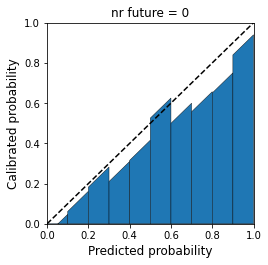

In [41]:
generate_rel_diagrams(np.clip(np.array(probs2), 0, 1), np.array(ys2))

In [42]:
area = np.array([[79,101],[79,121]])
indices_area = np.where((dist_means2[:, 0] >= area[0][0]) & (dist_means2[:, 0] < area[0][1]) & (dist_means2[:, 1] >= area[1][0]) & (dist_means2[:, 1] < area[1][1]))


ECE_abs: 0.033265048721100296
[0, 0, 0, 0, 4, 6, 3, 7, 10, 541]
Conf: [nan, nan, nan, nan, 0.4466681729339646, 0.5495089296491531, 0.6497245829452309, 0.7383543022390474, 0.82995697474802, 0.9990670844757269]
Acc: [nan, nan, nan, nan, 0.75, 1.0, 1.0, 1.0, 1.0, 0.9796672828096118]


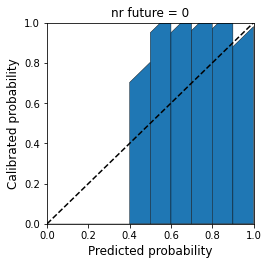

In [43]:
generate_rel_diagrams(np.clip(probs2, 0, 1)[indices_area[0]], ys2[indices_area[0]])